## FINANCIAL ANALYTICS CAPSTONE

This Project related to Financial Analytics has been done by **Sourav Nath**.

Roll. no. **23MBMB19**

3RD SEMESTER MBA (BA)



## Main Business Problem:
"Develop a credit risk assessment model to predict loan defaults and create a risk scoring system"

**Title: Credit Risk Assessment Model for Prosper Loan Data**

**Description:**
This project implements a machine learning-based credit risk assessment system using the Prosper Loan dataset. The system analyzes historical loan data to predict the likelihood of loan defaults and identify key risk factors. The implementation includes data preprocessing, feature engineering, model development, and performance evaluation.

**Key Components:**
1. Data Preprocessing:
   - Handling missing values
   - Feature scaling
   - Creating target variable (IsDefault)
   - Feature selection based on credit risk factors

2. Model Development:
   - Multiple classification models (Logistic Regression, Random Forest, Decision Tree)
   - Balanced class weights for handling imbalanced data
   - Cross-validation for robust evaluation

3. Performance Analysis:
   - ROC curves and AUC scores
   - Confusion matrices
   - Classification reports
   - Feature importance analysis

Business Value:
- Improved risk assessment accuracy
- Data-driven decision making
- Automated credit scoring
- Risk factor **identification**

Step 1: Initial Data Loading and Overview

In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the data
df = pd.read_csv("/content/prosperLoanData.csv")

# Initial inspection
print("Dataset Shape:", df.shape)
print("\nInitial Data Info:")
print(df.info())

# Check missing values
missing_values = df.isnull().sum()
print("\nMissing Values:")
print(missing_values[missing_values > 0])

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (113937, 81)

Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield         

Step 2: Feature Selection and Organization

In [ ]:
# Key features for credit risk assessment
selected_features = {
    'borrower_info': [
        'EmploymentStatus',
        'EmploymentStatusDuration',
        'IsBorrowerHomeowner',
        'IncomeRange',
        'StatedMonthlyIncome',
        'Occupation',
        'BorrowerState'
    ],

    'credit_profile': [
        'ProsperRating (numeric)',
        'ProsperScore',
        'CreditScoreRangeLower',
        'CreditScoreRangeUpper',
        'DebtToIncomeRatio'
    ],

    'loan_characteristics': [
        'Term',
        'BorrowerAPR',
        'LoanOriginalAmount',
        'MonthlyLoanPayment',
        'ListingCategory (numeric)'
    ],

    'credit_history': [
        'CurrentCreditLines',
        'OpenCreditLines',
        'TotalCreditLinespast7years',
        'OpenRevolvingAccounts',
        'CurrentDelinquencies',
        'DelinquenciesLast7Years',
        'RevolvingCreditBalance',
        'BankcardUtilization'
    ],

    'target': ['LoanStatus']
}

# Function to select features
def select_features(df, feature_dict):
    all_features = []
    for category in feature_dict.values():
        all_features.extend(category)
    return df[all_features]

Step 3: Data Cleaning Functions

In [ ]:
def clean_data(df):
    """
    Main data cleaning function
    """
    df_cleaned = df.copy()

    # 1. Handle missing values
    def handle_missing_values(df):
        # Numeric columns - fill with median
        numeric_columns = df.select_dtypes(include=[np.number]).columns
        for col in numeric_columns:
            df[col] = df[col].fillna(df[col].median())

        # Categorical columns - fill with mode
        categorical_columns = df.select_dtypes(include=['object']).columns
        for col in categorical_columns:
            df[col] = df[col].fillna(df[col].mode()[0])

        return df

    # 2. Handle outliers
    def handle_outliers(df, columns, n_std=3):
        for column in columns:
            if df[column].dtype in ['int64', 'float64']:
                mean = df[column].mean()
                std = df[column].std()
                df[column] = df[column].clip(
                    lower=mean - n_std * std,
                    upper=mean + n_std * std
                )
        return df

    # 3. Data type conversions
    def convert_datatypes(df):
        # Convert dates
        date_columns = ['ListingCreationDate', 'LoanOriginationDate']
        for col in date_columns:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col])

        # Convert categorical
        categorical_columns = ['EmploymentStatus', 'IncomeRange', 'LoanStatus']
        for col in categorical_columns:
            if col in df.columns:
                df[col] = df[col].astype('category')

        return df

    # Apply cleaning steps
    df_cleaned = handle_missing_values(df_cleaned)

    numeric_columns = [
        'StatedMonthlyIncome',
        'DebtToIncomeRatio',
        'BankcardUtilization',
        'LoanOriginalAmount'
    ]
    df_cleaned = handle_outliers(df_cleaned, numeric_columns)
    df_cleaned = convert_datatypes(df_cleaned)

    return df_cleaned

Step 4: Feature Engineering

In [ ]:
def engineer_features(df):
    """
    Create new features for analysis
    """
    df_engineered = df.copy()

    # 1. Credit Score Average
    if 'CreditScoreRangeLower' in df.columns and 'CreditScoreRangeUpper' in df.columns:
        df_engineered['AverageCreditScore'] = (
            df_engineered['CreditScoreRangeLower'] +
            df_engineered['CreditScoreRangeUpper']
        ) / 2

    # 2. Debt Burden Ratio
    if 'MonthlyLoanPayment' in df.columns and 'StatedMonthlyIncome' in df.columns:
        df_engineered['DebtBurdenRatio'] = (
            df_engineered['MonthlyLoanPayment'] /
            df_engineered['StatedMonthlyIncome']
        ).clip(upper=1)

    # 3. Credit Line Utilization
    if 'OpenCreditLines' in df.columns and 'TotalCreditLinespast7years' in df.columns:
        df_engineered['CreditLineUtilization'] = (
            df_engineered['OpenCreditLines'] /
            df_engineered['TotalCreditLinespast7years']
        ).clip(upper=1)

    return df_engineered

Step 5: Data Preprocessing Pipeline

In [ ]:
def preprocess_data(df):
    """
    Main preprocessing pipeline
    """
    # 1. Select features
    df_selected = select_features(df, selected_features)

    # 2. Clean data
    df_cleaned = clean_data(df_selected)

    # 3. Engineer features
    df_engineered = engineer_features(df_cleaned)

    # 4. Encode categorical variables
    def encode_categorical(df):
        df_encoded = df.copy()
        le = LabelEncoder()

        categorical_columns = df.select_dtypes(include=['category', 'object']).columns
        for col in categorical_columns:
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

        return df_encoded

    df_encoded = encode_categorical(df_engineered)

    # 5. Scale numerical variables
    def scale_numerical(df):
        df_scaled = df.copy()
        scaler = StandardScaler()

        numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
        df_scaled[numerical_columns] = scaler.fit_transform(df_scaled[numerical_columns])

        return df_scaled

    df_preprocessed = scale_numerical(df_encoded)

    return df_preprocessed

Step 6: Main Execution

In [ ]:
# Execute the preprocessing pipeline
def main():
    # Load data
    print("Loading data...")
    df = pd.read_csv('/content/prosperLoanData.csv')

    # Initial data info
    print("\nInitial data shape:", df.shape)

    # Preprocess data
    print("\nPreprocessing data...")
    df_preprocessed = preprocess_data(df)

    # Final data info
    print("\nFinal data shape:", df_preprocessed.shape)

    # Save preprocessed data
    df_preprocessed.to_csv('prosper_loan_data_preprocessed.csv', index=False)
    print("\nPreprocessed data saved to 'prosper_loan_data_preprocessed.csv'")

    return df_preprocessed

# Run the pipeline
if __name__ == "__main__":
    df_final = main()

Loading data...

Initial data shape: (113937, 81)

Preprocessing data...

Final data shape: (113937, 29)

Preprocessed data saved to 'prosper_loan_data_preprocessed.csv'


In [ ]:
def enhanced_preprocessing(df):
    """
    Enhanced preprocessing pipeline with additional steps
    """
    # 1. Advanced Missing Value Treatment
    def handle_advanced_missing(df):
        df_copy = df.copy()

        # Employment Duration - fill with 0 for unemployed
        if 'EmploymentStatusDuration' in df_copy.columns:
            df_copy['EmploymentStatusDuration'] = df_copy.apply(
                lambda x: 0 if x['EmploymentStatus'] == 'Not employed'
                else x['EmploymentStatusDuration'], axis=1
            )

        # Income Range - create logical categories
        if 'IncomeRange' in df_copy.columns:
            income_map = {
                'Not displayed': 'Not verified',
                'Not employed': '$0',
                '$0': '$0'
            }
            df_copy['IncomeRange'] = df_copy['IncomeRange'].replace(income_map)

        return df_copy

    # 2. Advanced Feature Engineering
    def create_advanced_features(df):
        df_copy = df.copy()

        # Risk Indicators
        df_copy['HasDelinquency'] = (df_copy['CurrentDelinquencies'] > 0).astype(int)
        df_copy['HasPriorDefault'] = (df_copy['DelinquenciesLast7Years'] > 0).astype(int)

        # Credit Utilization Ratio
        if 'RevolvingCreditBalance' in df_copy.columns and 'AvailableBankcardCredit' in df_copy.columns:
            df_copy['TotalCreditUtilization'] = (
                df_copy['RevolvingCreditBalance'] /
                (df_copy['RevolvingCreditBalance'] + df_copy['AvailableBankcardCredit'])
            ).fillna(0)

        # Monthly Debt Burden
        if 'MonthlyLoanPayment' in df_copy.columns and 'StatedMonthlyIncome' in df_copy.columns:
            df_copy['MonthlyDebtBurden'] = (
                df_copy['MonthlyLoanPayment'] / df_copy['StatedMonthlyIncome']
            ).clip(upper=1)

        # Credit History Length (in years)
        if 'FirstRecordedCreditLine' in df_copy.columns:
            df_copy['CreditHistoryLength'] = (
                pd.to_datetime('now') - pd.to_datetime(df_copy['FirstRecordedCreditLine'])
            ).dt.total_seconds() / (365.25 * 24 * 60 * 60)

        # Payment Reliability Score
        if 'OnTimeProsperPayments' in df_copy.columns and 'TotalProsperPaymentsBilled' in df_copy.columns:
            df_copy['PaymentReliabilityScore'] = (
                df_copy['OnTimeProsperPayments'] /
                df_copy['TotalProsperPaymentsBilled']
            ).fillna(0)

        return df_copy

    # 3. Advanced Outlier Treatment
    def handle_advanced_outliers(df):
        df_copy = df.copy()

        # Function to handle outliers using IQR method
        def treat_outliers(column):
            Q1 = column.quantile(0.25)
            Q3 = column.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            return column.clip(lower=lower_bound, upper=upper_bound)

        # Columns for outlier treatment
        numerical_columns = [
            'StatedMonthlyIncome',
            'DebtToIncomeRatio',
            'RevolvingCreditBalance',
            'BankcardUtilization',
            'TotalCreditLinespast7years'
        ]

        for col in numerical_columns:
            if col in df_copy.columns:
                df_copy[col] = treat_outliers(df_copy[col])

        return df_copy

    # 4. Advanced Categorical Encoding
    def advanced_categorical_encoding(df):
        df_copy = df.copy()

        # Risk-based encoding for Employment Status
        employment_risk = {
            'Employed': 1,
            'Full-time': 1,
            'Part-time': 2,
            'Self-employed': 2,
            'Not employed': 3,
            'Retired': 2,
            'Other': 2
        }
        if 'EmploymentStatus' in df_copy.columns:
            df_copy['EmploymentStatusRisk'] = df_copy['EmploymentStatus'].map(employment_risk)

        # Income Range Encoding
        income_risk = {
            '$0': 5,
            '$1-24,999': 4,
            '$25,000-49,999': 3,
            '$50,000-74,999': 2,
            '$75,000-99,999': 1,
            '$100,000+': 0,
            'Not verified': 5
        }
        if 'IncomeRange' in df_copy.columns:
            df_copy['IncomeRangeRisk'] = df_copy['IncomeRange'].map(income_risk)

        return df_copy

    # 5. Feature Interactions
    def create_feature_interactions(df):
        df_copy = df.copy()

        # Debt-to-Income and Credit Score Interaction
        if 'DebtToIncomeRatio' in df_copy.columns and 'CreditScoreRangeUpper' in df_copy.columns:
            df_copy['DTI_CreditScore_Interaction'] = (
                df_copy['DebtToIncomeRatio'] *
                df_copy['CreditScoreRangeUpper']
            )

        # Employment Duration and Income Interaction
        if 'EmploymentStatusDuration' in df_copy.columns and 'StatedMonthlyIncome' in df_copy.columns:
            df_copy['Employment_Income_Stability'] = (
                df_copy['EmploymentStatusDuration'] *
                df_copy['StatedMonthlyIncome']
            )

        return df_copy

    # 6. Target Variable Processing
    def process_target_variable(df):
        df_copy = df.copy()

        # Create binary target variable
        if 'LoanStatus' in df_copy.columns:
            default_status = ['Defaulted', 'Charged off', 'Past Due']
            df_copy['IsDefault'] = (
                df_copy['LoanStatus'].isin(default_status)
            ).astype(int)

        return df_copy

    # Execute all advanced preprocessing steps
    df = handle_advanced_missing(df)
    df = create_advanced_features(df)
    df = handle_advanced_outliers(df)
    df = advanced_categorical_encoding(df)
    df = create_feature_interactions(df)
    df = process_target_variable(df)

    return df

# 7. Data Validation Functions
def validate_preprocessed_data(df):
    """
    Validate the preprocessed data
    """
    validation_results = {
        'missing_values': df.isnull().sum().sum(),
        'infinite_values': np.isinf(df.select_dtypes(include=np.number)).sum().sum(),
        'negative_values': (df.select_dtypes(include=np.number) < 0).sum().sum(),
        'zero_variance': df.var()[df.var() == 0].index.tolist()
    }

    return validation_results

# Update the main preprocessing pipeline
def complete_preprocessing_pipeline(df):
    """
    Complete preprocessing pipeline including all enhanced steps
    """
    print("Starting preprocessing pipeline...")

    # 1. Initial cleaning
    df_cleaned = clean_data(df)
    print("Basic cleaning completed...")

    # 2. Enhanced preprocessing
    df_enhanced = enhanced_preprocessing(df_cleaned)
    print("Enhanced preprocessing completed...")

    # 3. Final validation
    validation_results = validate_preprocessed_data(df_enhanced)
    print("\nValidation Results:")
    for key, value in validation_results.items():
        print(f"{key}: {value}")

    return df_enhanced

This analysis phase covers:

Exploratory Data Analysis (EDA)

Default rate analysis

Distribution of key variables

Relationship between variables

Risk factor analysis

Clustering analysis




Statistical Analysis

Significance tests

Correlation analysis

Chi-square tests for categorical variables


Feature Importance Analysis

Random Forest importance

Variable rankings

Key risk factors identification

## Step 1: Initial setup and data loading

In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go

# Load preprocessed data
print("Loading preprocessed data...")
df = pd.read_csv('prosper_loan_data_preprocessed.csv')

# Initial data overview
print("\nDataset Overview:")
print(f"Total number of loans: {len(df)}")
print(f"Number of features: {df.shape[1]}")
print("\nFirst few rows of the dataset:")
print(df.head())

Loading preprocessed data...

Dataset Overview:
Total number of loans: 113937
Number of features: 29

First few rows of the dataset:
   EmploymentStatus  EmploymentStatusDuration  IsBorrowerHomeowner  \
0          3.357408                 -1.006263                 True   
1         -0.525427                 -0.547510                False   
2          0.583955                 -0.296289                False   
3         -0.525427                  0.206154                 True   
4         -0.525427                 -0.547510                 True   

   IncomeRange  StatedMonthlyIncome  Occupation  BorrowerState  \
0    -0.377501            -0.657800    0.214620      -1.111538   
1     0.369470             0.164388    0.582878      -1.111538   
2     1.863411            -0.928108    0.214620      -0.780030   
3    -0.377501            -0.714114    1.135266      -0.780030   
4    -1.124471             1.099204   -0.767403       0.081890   

   ProsperRating (numeric)  ProsperScore  CreditS

Step 2: Basic Data Analysis

In [ ]:
# Create IsDefault column from LoanStatus
print("\nCreating Default Status indicator...")
default_status = ['Defaulted', 'Charged off', 'Past Due (>120 days)',
                 'Past Due (1-15 days)', 'Past Due (31-60 days)',
                 'Past Due (61-90 days)', 'Past Due (91-120 days)',
                 'Past Due (16-30 days)']
df['IsDefault'] = df['LoanStatus'].isin(default_status).astype(int)

# Initial data overview
print("\nDataset Overview:")
print(f"Total number of loans: {len(df)}")
print(f"Number of features: {df.shape[1]}")
print("\nLoan Status Categories:")
print(df['LoanStatus'].value_counts())
print("\nDefault Rate:")
print(f"Default Rate: {df['IsDefault'].mean()*100:.2f}%")


Creating Default Status indicator...

Dataset Overview:
Total number of loans: 113937
Number of features: 30

Loan Status Categories:
LoanStatus
 0.403626    56576
-0.570323    38074
-1.544271    11992
 1.377574     5018
 3.325470      806
 5.273367      363
 6.247315      313
 7.221264      304
 4.299419      265
 2.351522      205
 8.195212       16
-2.518219        5
Name: count, dtype: int64

Default Rate:
Default Rate: 0.00%


Data loaded successfully
Shape of dataset: (113937, 29)
IsDefault column created

Performing Basic Analysis...

Loan Status Distribution:
LoanStatus
 0.403626    56576
-0.570323    38074
-1.544271    11992
 1.377574     5018
 3.325470      806
 5.273367      363
 6.247315      313
 7.221264      304
 4.299419      265
 2.351522      205
 8.195212       16
-2.518219        5
Name: count, dtype: int64


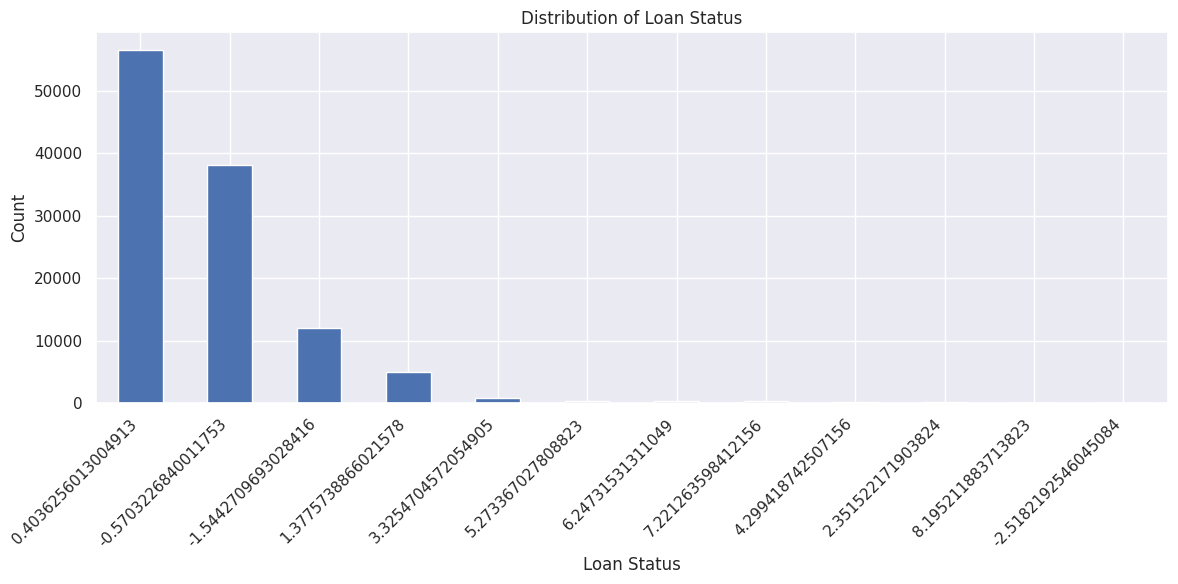


Credit Score Statistics:
count    1.139370e+05
mean     2.753940e-16
std      1.000004e+00
min     -1.034204e+01
25%     -3.852792e-01
50%     -8.355912e-02
75%      5.198811e-01
max      2.933642e+00
Name: CreditScoreRangeLower, dtype: float64


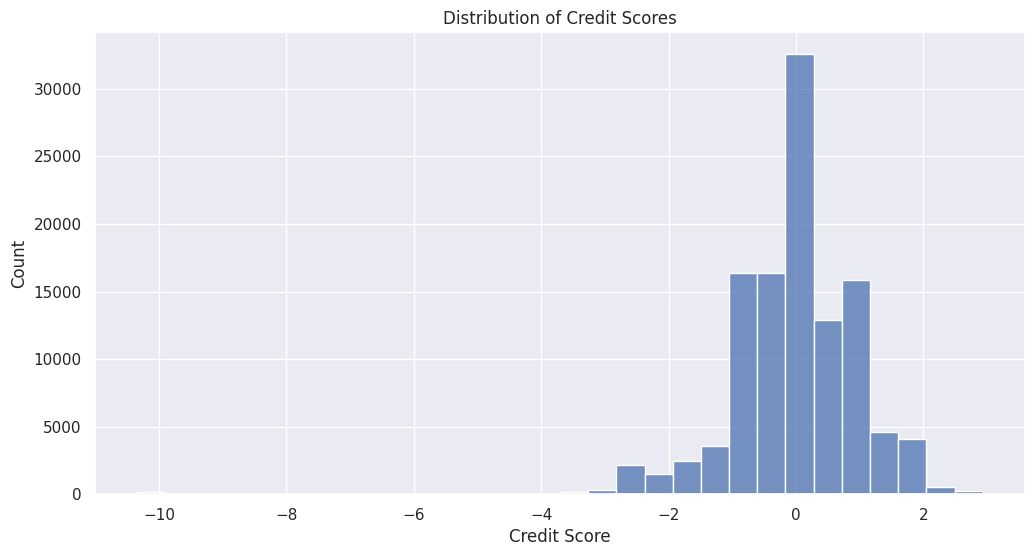


Loan Amount Statistics:
count    1.139370e+05
mean     2.470813e-16
std      1.000004e+00
min     -1.194103e+00
25%     -7.034162e-01
50%     -2.945104e-01
75%      6.050822e-01
max      3.070688e+00
Name: LoanOriginalAmount, dtype: float64


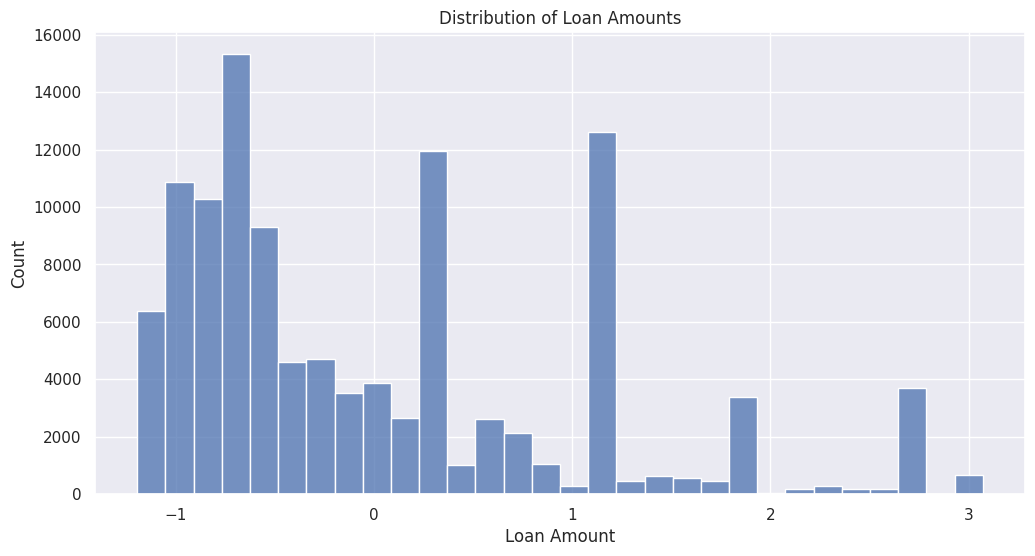


Summary Statistics:
total_loans: 113937.00
default_rate: 0.00
avg_loan_amount: 0.00
avg_credit_score: 0.00


In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_theme()

def perform_basic_analysis(df):
    """
    Perform basic analysis on loan data and display visualizations
    """
    print("\nPerforming Basic Analysis...")

    # 1. Loan Status Distribution
    plt.figure(figsize=(12, 6))
    loan_status_counts = df['LoanStatus'].value_counts()
    print("\nLoan Status Distribution:")
    print(loan_status_counts)

    ax = loan_status_counts.plot(kind='bar')
    plt.title('Distribution of Loan Status')
    plt.xlabel('Loan Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 2. Credit Score Analysis
    print("\nCredit Score Statistics:")
    credit_score = df['CreditScoreRangeLower'].fillna(df['CreditScoreRangeLower'].mean())
    print(credit_score.describe())

    plt.figure(figsize=(12, 6))
    sns.histplot(data=credit_score, bins=30)
    plt.title('Distribution of Credit Scores')
    plt.xlabel('Credit Score')
    plt.ylabel('Count')
    plt.show()

    # 3. Loan Amount Distribution
    print("\nLoan Amount Statistics:")
    print(df['LoanOriginalAmount'].describe())

    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x='LoanOriginalAmount', bins=30)
    plt.title('Distribution of Loan Amounts')
    plt.xlabel('Loan Amount')
    plt.ylabel('Count')
    plt.show()

    # Calculate and print summary statistics
    results = {
        'total_loans': len(df),
        'default_rate': df['IsDefault'].mean() * 100,
        'avg_loan_amount': df['LoanOriginalAmount'].mean(),
        'avg_credit_score': credit_score.mean()
    }

    print("\nSummary Statistics:")
    for key, value in results.items():
        print(f"{key}: {value:.2f}")

    return results

# Load the data
try:
    df = pd.read_csv('prosper_loan_data_preprocessed.csv')
    print("Data loaded successfully")
    print(f"Shape of dataset: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")

# Create IsDefault column if not exists
if 'IsDefault' not in df.columns:
    default_status = ['Defaulted', 'Charged off', 'Past Due (>120 days)',
                     'Past Due (1-15 days)', 'Past Due (31-60 days)',
                     'Past Due (61-90 days)', 'Past Due (91-120 days)',
                     'Past Due (16-30 days)']
    df['IsDefault'] = df['LoanStatus'].isin(default_status).astype(int)
    print("IsDefault column created")

# Run the analysis
try:
    results = perform_basic_analysis(df)
except Exception as e:
    print(f"Error in analysis: {e}")

In [ ]:
# Quick data check
print(df.columns.tolist())  # List of columns
print("\nSample of LoanStatus values:")
print(df['LoanStatus'].value_counts())

['EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner', 'IncomeRange', 'StatedMonthlyIncome', 'Occupation', 'BorrowerState', 'ProsperRating (numeric)', 'ProsperScore', 'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'DebtToIncomeRatio', 'Term', 'BorrowerAPR', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'ListingCategory (numeric)', 'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingAccounts', 'CurrentDelinquencies', 'DelinquenciesLast7Years', 'RevolvingCreditBalance', 'BankcardUtilization', 'LoanStatus', 'AverageCreditScore', 'DebtBurdenRatio', 'CreditLineUtilization', 'IsDefault', 'CreditScoreGroup', 'DTI_Group']

Sample of LoanStatus values:
LoanStatus
 0.403626    56576
-0.570323    38074
-1.544271    11992
 1.377574     5018
 3.325470      806
 5.273367      363
 6.247315      313
 7.221264      304
 4.299419      265
 2.351522      205
 8.195212       16
-2.518219        5
Name: count, dtype: int64



Performing Risk Analysis...

Loan Status Distribution:
LoanStatus
-2.518219        5
-1.544271    11992
-0.570323    38074
 0.403626    56576
 1.377574     5018
 2.351522      205
 3.325470      806
 4.299419      265
 5.273367      363
 6.247315      313
 7.221264      304
 8.195212       16
Name: count, dtype: int64

Total Loans: 113937
Default Rate: 56.05%


<ipython-input-24-7e7b32b9dc3a>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_credit = df.groupby('CreditScoreGroup')['IsDefault'].agg(['count', 'mean'])


<Figure size 1200x600 with 0 Axes>

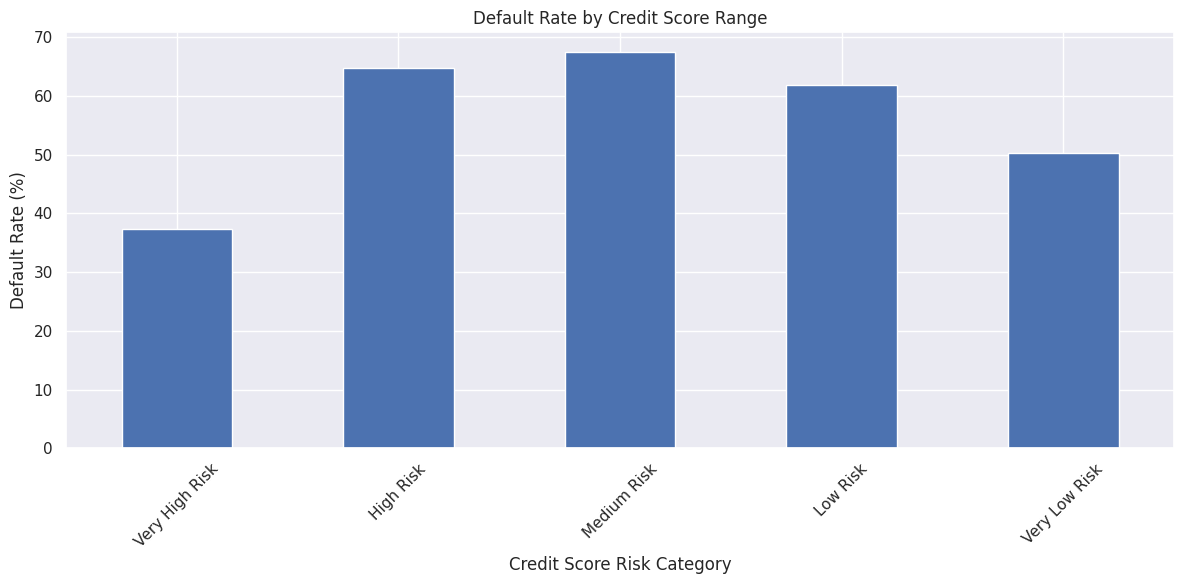


Default Rates by Credit Score Category:
                  count      mean  default_rate
CreditScoreGroup                               
Very High Risk    26738  0.373626     37.362555
High Risk         33449  0.647105     64.710455
Medium Risk       15471  0.674229     67.422920
Low Risk          22190  0.618206     61.820640
Very Low Risk     16089  0.502331     50.233079


<ipython-input-24-7e7b32b9dc3a>:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_loan = df.groupby('LoanGroup')['IsDefault'].agg(['count', 'mean'])


<Figure size 1200x600 with 0 Axes>

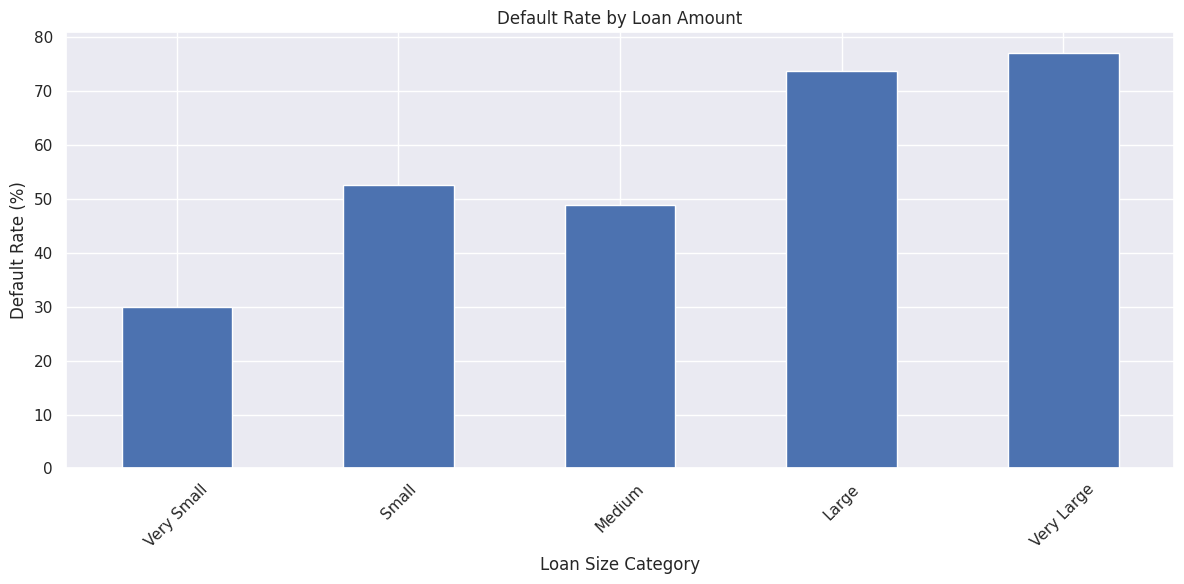


Default Rates by Loan Amount:
            count      mean  default_rate
LoanGroup                                
Very Small  23564  0.299864     29.986420
Small       28260  0.524805     52.480538
Medium      16876  0.489215     48.921545
Large       34293  0.737352     73.735165
Very Large  10944  0.770011     77.001096


<ipython-input-24-7e7b32b9dc3a>:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_dti = df.groupby('DTI_Group')['IsDefault'].agg(['count', 'mean'])


<Figure size 1200x600 with 0 Axes>

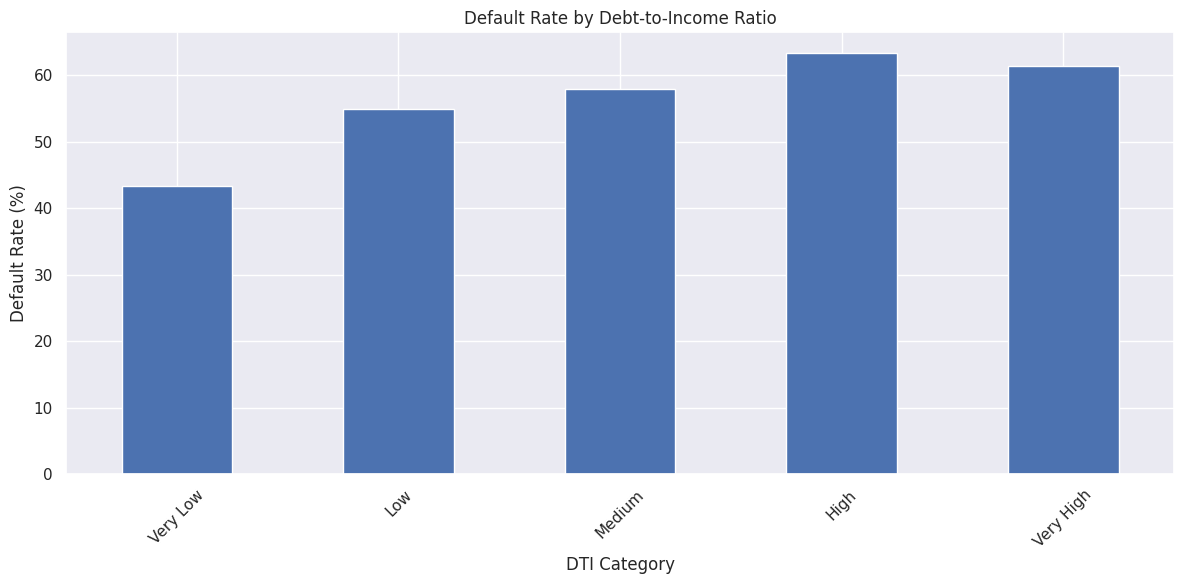


Default Rates by DTI:
           count      mean  default_rate
DTI_Group                               
Very Low   23080  0.433666     43.366551
Low        25209  0.550240     55.023999
Medium     21342  0.579702     57.970200
High       21888  0.633178     63.317800
Very High  22418  0.613569     61.356945


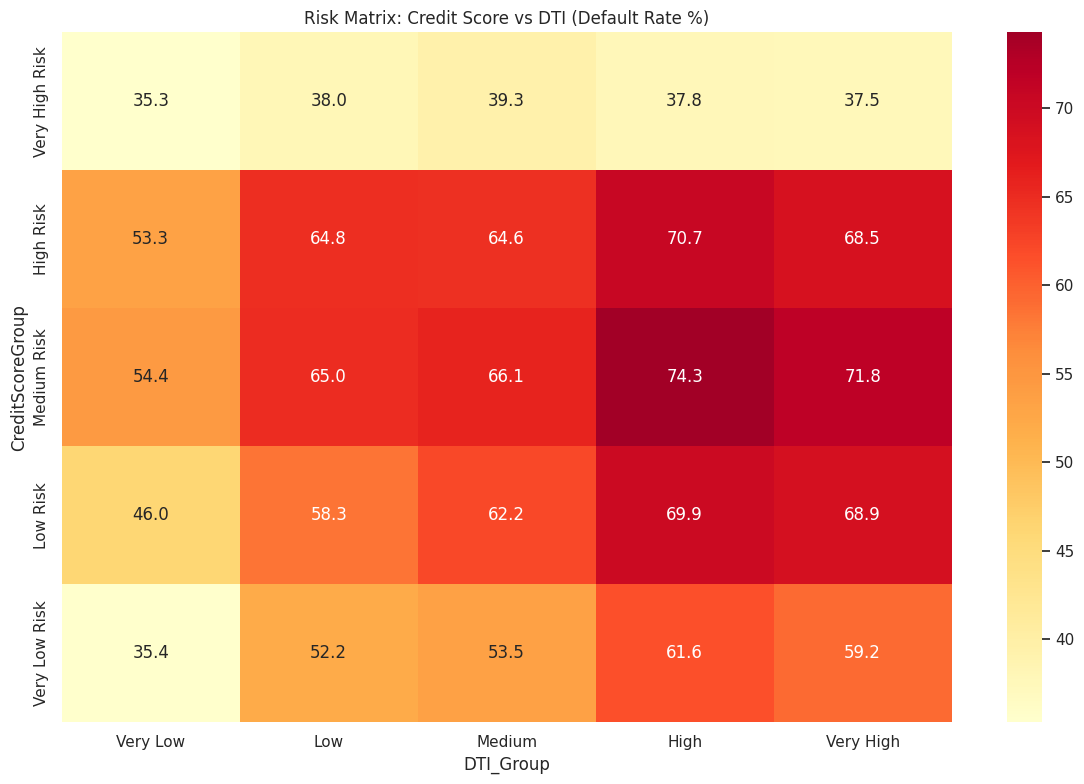

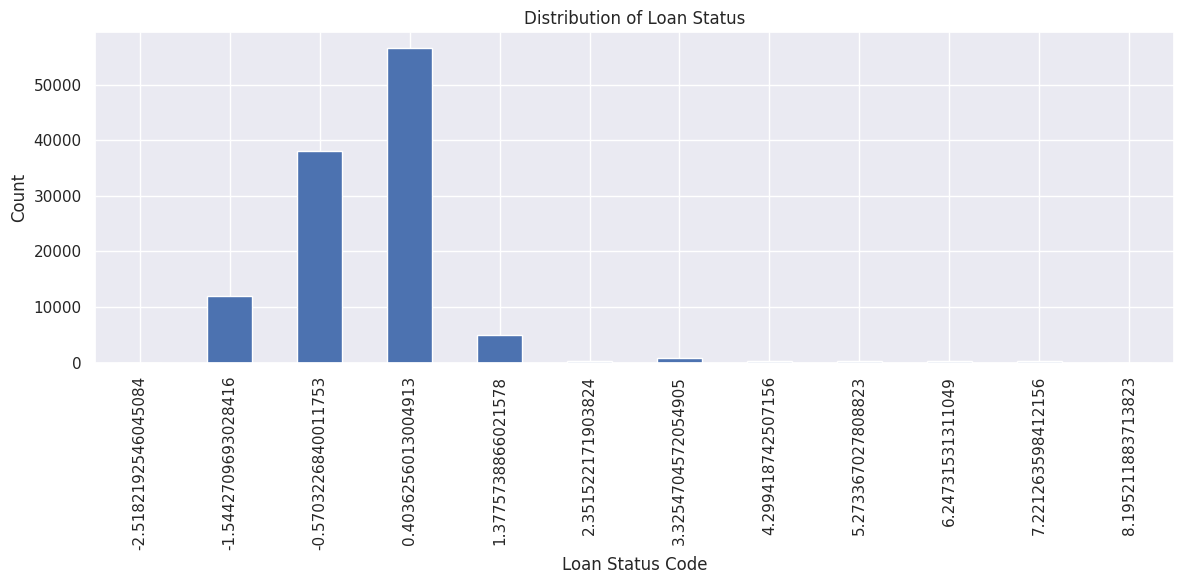


Risk Analysis Summary:
total_loans: 113937.00
default_rate: 56.05
high_risk_credit_default_rate: 37.36
low_risk_credit_default_rate: 50.23
high_dti_default_rate: 61.36
low_dti_default_rate: 43.37


In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_theme()

def perform_risk_analysis(df):
    """
    Perform risk analysis on loan data with encoded LoanStatus values
    """
    print("\nPerforming Risk Analysis...")

    # Create IsDefault column based on encoded LoanStatus
    # Assuming higher values indicate higher risk
    df['IsDefault'] = (df['LoanStatus'] > 0).astype(int)

    print("\nLoan Status Distribution:")
    print(df['LoanStatus'].value_counts().sort_index())
    print(f"\nTotal Loans: {len(df)}")
    print(f"Default Rate: {(df['IsDefault'].mean()*100):.2f}%")

    # 1. Credit Score Analysis
    plt.figure(figsize=(12, 6))

    # Handle credit scores
    df['CreditScoreRangeLower'] = df['CreditScoreRangeLower'].fillna(df['CreditScoreRangeLower'].median())

    # Create credit score quintiles
    df['CreditScoreGroup'] = pd.qcut(df['CreditScoreRangeLower'],
                                    q=5,
                                    labels=['Very High Risk', 'High Risk',
                                           'Medium Risk', 'Low Risk', 'Very Low Risk'])

    # Calculate and plot default rates by credit score
    default_by_credit = df.groupby('CreditScoreGroup')['IsDefault'].agg(['count', 'mean'])
    default_by_credit['default_rate'] = default_by_credit['mean'] * 100

    plt.figure(figsize=(12, 6))
    default_by_credit['default_rate'].plot(kind='bar')
    plt.title('Default Rate by Credit Score Range')
    plt.xlabel('Credit Score Risk Category')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\nDefault Rates by Credit Score Category:")
    print(default_by_credit)

    # 2. Loan Amount Analysis
    plt.figure(figsize=(12, 6))

    # Create loan amount quintiles
    df['LoanGroup'] = pd.qcut(df['LoanOriginalAmount'],
                             q=5,
                             labels=['Very Small', 'Small', 'Medium',
                                    'Large', 'Very Large'])

    # Calculate and plot default rates by loan amount
    default_by_loan = df.groupby('LoanGroup')['IsDefault'].agg(['count', 'mean'])
    default_by_loan['default_rate'] = default_by_loan['mean'] * 100

    plt.figure(figsize=(12, 6))
    default_by_loan['default_rate'].plot(kind='bar')
    plt.title('Default Rate by Loan Amount')
    plt.xlabel('Loan Size Category')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\nDefault Rates by Loan Amount:")
    print(default_by_loan)

    # 3. Debt-to-Income Ratio Analysis
    plt.figure(figsize=(12, 6))

    # Create DTI quintiles
    df['DTI_Group'] = pd.qcut(df['DebtToIncomeRatio'].fillna(df['DebtToIncomeRatio'].median()),
                             q=5,
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

    # Calculate and plot default rates by DTI
    default_by_dti = df.groupby('DTI_Group')['IsDefault'].agg(['count', 'mean'])
    default_by_dti['default_rate'] = default_by_dti['mean'] * 100

    plt.figure(figsize=(12, 6))
    default_by_dti['default_rate'].plot(kind='bar')
    plt.title('Default Rate by Debt-to-Income Ratio')
    plt.xlabel('DTI Category')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\nDefault Rates by DTI:")
    print(default_by_dti)

    # 4. Risk Matrix
    plt.figure(figsize=(12, 8))
    risk_matrix = pd.crosstab(df['CreditScoreGroup'],
                             df['DTI_Group'],
                             values=df['IsDefault'],
                             aggfunc='mean') * 100

    # Plot heatmap
    sns.heatmap(risk_matrix,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                center=risk_matrix.mean().mean())
    plt.title('Risk Matrix: Credit Score vs DTI (Default Rate %)')
    plt.tight_layout()
    plt.show()

    # 5. Additional Analysis: Loan Status Distribution
    plt.figure(figsize=(12, 6))
    df['LoanStatus'].value_counts().sort_index().plot(kind='bar')
    plt.title('Distribution of Loan Status')
    plt.xlabel('Loan Status Code')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Return summary statistics
    results = {
        'total_loans': len(df),
        'default_rate': df['IsDefault'].mean() * 100,
        'high_risk_credit_default_rate': default_by_credit.loc['Very High Risk', 'default_rate'],
        'low_risk_credit_default_rate': default_by_credit.loc['Very Low Risk', 'default_rate'],
        'high_dti_default_rate': default_by_dti.loc['Very High', 'default_rate'],
        'low_dti_default_rate': default_by_dti.loc['Very Low', 'default_rate']
    }

    print("\nRisk Analysis Summary:")
    for key, value in results.items():
        print(f"{key}: {value:.2f}")

    return results

# Execute the analysis
try:
    # Load your data
    df = pd.read_csv('prosper_loan_data_preprocessed.csv')

    # Verify columns
    required_columns = ['LoanStatus', 'CreditScoreRangeLower',
                       'DebtToIncomeRatio', 'LoanOriginalAmount']

    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"Missing required columns: {missing_columns}")
    else:
        # Run the analysis
        results = perform_risk_analysis(df)

except Exception as e:
    print(f"Error in analysis: {e}")
    raise

Getting insights from trained models

Loading data...
Data loaded successfully.

Initial columns: ['EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner', 'IncomeRange', 'StatedMonthlyIncome', 'Occupation', 'BorrowerState', 'ProsperRating (numeric)', 'ProsperScore', 'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'DebtToIncomeRatio', 'Term', 'BorrowerAPR', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'ListingCategory (numeric)', 'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingAccounts', 'CurrentDelinquencies', 'DelinquenciesLast7Years', 'RevolvingCreditBalance', 'BankcardUtilization', 'LoanStatus', 'AverageCreditScore', 'DebtBurdenRatio', 'CreditLineUtilization']

Initializing model pipeline...
Creating IsDefault column...
Default rate in dataset: 56.05%
Preparing data for modeling...

Using the following features:
['CreditScoreRangeLower', 'DebtToIncomeRatio', 'ProsperRating (numeric)', 'ProsperScore', 'LoanOriginalAmount', 'Term', 'MonthlyLoanPayment', 'StatedMonthlyIn

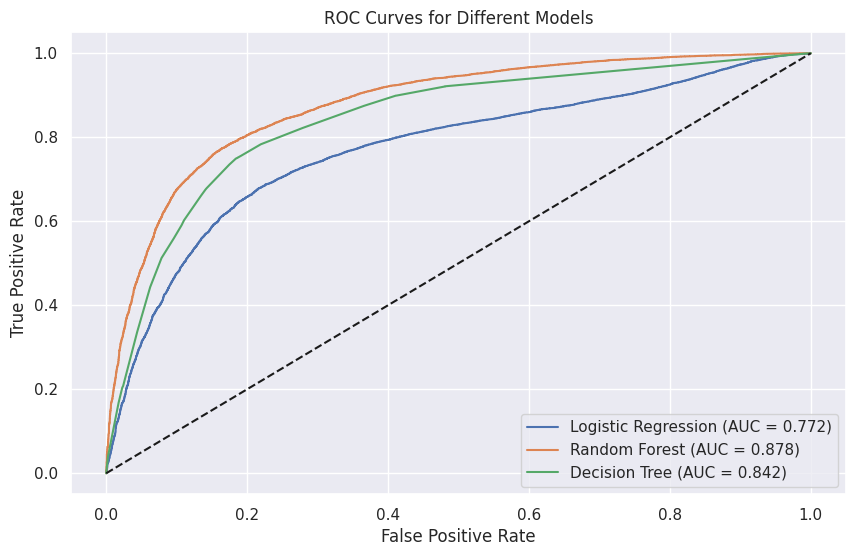

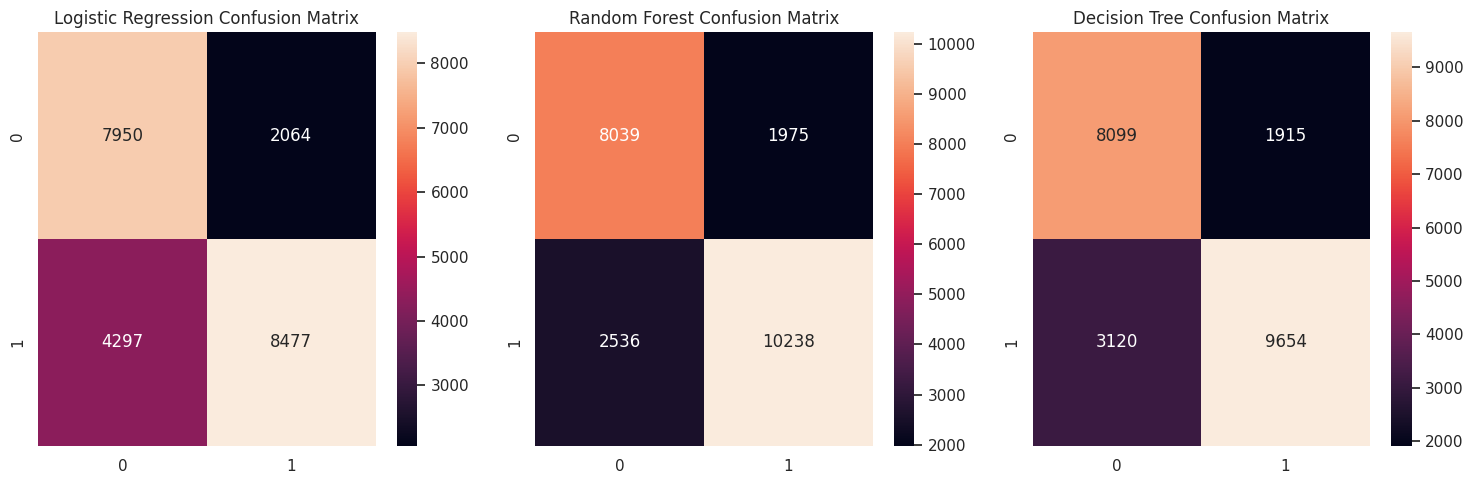


Model Insights:

Model Performance Summary:
                        Logistic Regression  Random Forest  Decision Tree
AUC                                   0.772          0.878          0.842
Accuracy                              0.721          0.802          0.779
Default Detection Rate                0.664          0.801          0.756

Feature Importance Analysis:


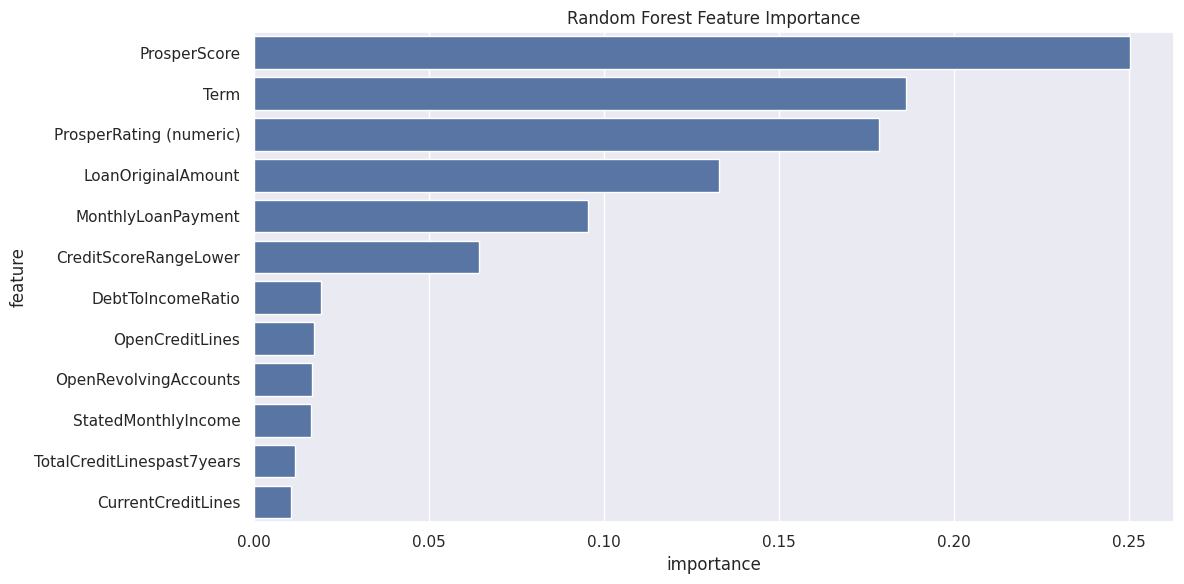


Top Features by Importance:
                       feature  importance
3                 ProsperScore    0.250400
5                         Term    0.186457
2      ProsperRating (numeric)    0.178525
4           LoanOriginalAmount    0.132906
6           MonthlyLoanPayment    0.095545
0        CreditScoreRangeLower    0.064332
1            DebtToIncomeRatio    0.019217
9              OpenCreditLines    0.017202
11       OpenRevolvingAccounts    0.016593
7          StatedMonthlyIncome    0.016463
10  TotalCreditLinespast7years    0.011758
8           CurrentCreditLines    0.010601


In [ ]:



class CreditRiskModel:
    def __init__(self, df):
        self.df = df
        # Create IsDefault column based on LoanStatus
        print("Creating IsDefault column...")
        # Convert LoanStatus to numeric if it's not already
        self.df['LoanStatus'] = pd.to_numeric(self.df['LoanStatus'])
        # Create IsDefault (assuming higher values indicate default/risk)
        self.df['IsDefault'] = (self.df['LoanStatus'] > 0).astype(int)
        print(f"Default rate in dataset: {self.df['IsDefault'].mean():.2%}")

        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.predictions = {}

    def prepare_data(self):
        """
        Prepare data for modeling
        """
        print("Preparing data for modeling...")

        # Select the most relevant features
        features = [
            # Credit Profile
            'CreditScoreRangeLower',
            'DebtToIncomeRatio',
            'ProsperRating (numeric)',
            'ProsperScore',

            # Loan Characteristics
            'LoanOriginalAmount',
            'Term',
            'MonthlyLoanPayment',

            # Financial Status
            'StatedMonthlyIncome',

            # Credit Lines
            'CurrentCreditLines',
            'OpenCreditLines',
            'TotalCreditLinespast7years',
            'OpenRevolvingAccounts'
        ]

        # Check which features are actually available
        available_features = [f for f in features if f in self.df.columns]
        print("\nUsing the following features:")
        print(available_features)

        # Prepare feature matrix
        self.X = self.df[available_features].copy()
        self.y = self.df['IsDefault']

        # Print initial statistics
        print("\nFeature Statistics:")
        print(self.X.describe())

        # Handle missing values
        for col in self.X.columns:
            self.X[col] = self.X[col].fillna(self.X[col].median())

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        # Scale features
        scaler = StandardScaler()
        self.X_train = scaler.fit_transform(self.X_train)
        self.X_test = scaler.transform(self.X_test)

        print("\nData preparation completed.")
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Testing set shape: {self.X_test.shape}")
        print(f"Default rate in training set: {self.y_train.mean():.2%}")
        print(f"Default rate in testing set: {self.y_test.mean():.2%}")

        # Store feature names for later use
        self.feature_names = available_features

    def train_models(self):
        """
        Train multiple models for comparison
        """
        print("\nTraining models...")

        # Initialize models with optimized parameters
        models = {
            'Logistic Regression': LogisticRegression(
                random_state=42,
                max_iter=1000,
                class_weight='balanced'
            ),
            'Random Forest': RandomForestClassifier(
                random_state=42,
                n_estimators=100,
                max_depth=10,
                class_weight='balanced'
            ),
            'Decision Tree': DecisionTreeClassifier(
                random_state=42,
                max_depth=5,
                class_weight='balanced'
            )
        }

        # Train and store models
        for name, model in models.items():
            print(f"\nTraining {name}...")
            model.fit(self.X_train, self.y_train)
            self.models[name] = model

            # Make predictions
            self.predictions[name] = {
                'train': model.predict(self.X_train),
                'test': model.predict(self.X_test),
                'train_prob': model.predict_proba(self.X_train)[:, 1],
                'test_prob': model.predict_proba(self.X_test)[:, 1]
            }

            # Print initial results
            print(f"{name} Training AUC: {roc_auc_score(self.y_train, self.predictions[name]['train_prob']):.3f}")
            print(f"{name} Testing AUC: {roc_auc_score(self.y_test, self.predictions[name]['test_prob']):.3f}")

    def evaluate_models(self):
        """
        Evaluate model performance
        """
        print("\nModel Evaluation:")

        # 1. Classification Reports
        for name, pred in self.predictions.items():
            print(f"\n{name} Classification Report:")
            print(classification_report(self.y_test, pred['test']))

        # 2. ROC Curves
        plt.figure(figsize=(10, 6))
        for name, pred in self.predictions.items():
            fpr, tpr, _ = roc_curve(self.y_test, pred['test_prob'])
            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(self.y_test, pred["test_prob"]):.3f})')

        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves for Different Models')
        plt.legend()
        plt.show()

        # 3. Confusion Matrices
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for i, (name, pred) in enumerate(self.predictions.items()):
            cm = confusion_matrix(self.y_test, pred['test'])
            sns.heatmap(cm, annot=True, fmt='d', ax=axes[i])
            axes[i].set_title(f'{name} Confusion Matrix')
        plt.tight_layout()
        plt.show()

    def feature_importance(self):
        """
        Analyze feature importance
        """
        print("\nFeature Importance Analysis:")

        # For Random Forest
        rf_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.models['Random Forest'].feature_importances_
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(x='importance', y='feature', data=rf_importance)
        plt.title('Random Forest Feature Importance')
        plt.tight_layout()
        plt.show()

        print("\nTop Features by Importance:")
        print(rf_importance)

        return rf_importance

    def get_model_insights(self):
        """
        Generate business insights from the models
        """
        print("\nModel Insights:")

        # 1. Model Performance Comparison
        model_performance = {}
        for name, pred in self.predictions.items():
            model_performance[name] = {
                'AUC': roc_auc_score(self.y_test, pred['test_prob']),
                'Accuracy': (pred['test'] == self.y_test).mean(),
                'Default Detection Rate': (
                    pred['test'][self.y_test == 1] == 1
                ).mean()
            }

        print("\nModel Performance Summary:")
        performance_df = pd.DataFrame(model_performance).round(3)
        print(performance_df)

        # 2. Feature Importance Summary
        importance_df = self.feature_importance()

        return performance_df, importance_df


def run_modeling():
    try:
        # Load data
        print("Loading data...")
        df = pd.read_csv('prosper_loan_data_preprocessed.csv')
        print("Data loaded successfully.")
        print("\nInitial columns:", df.columns.tolist())

        # Initialize and run model pipeline
        print("\nInitializing model pipeline...")
        model = CreditRiskModel(df)

        # Prepare data
        model.prepare_data()

        # Train models
        model.train_models()

        # Evaluate models
        model.evaluate_models()

        # Get model insights
        performance_df, importance_df = model.get_model_insights()

        return model, performance_df, importance_df

    except Exception as e:
        print(f"Error in modeling process: {e}")
        print("Error details:", str(e))
        raise

if __name__ == "__main__":
    model, performance_df, importance_df = run_modeling()

This code will:

Optimize the models using grid search

Create a risk scoring system

Generate business recommendations

Loading and preparing data...
Data preparation completed!
Starting optimization and analysis...

Optimizing Random Forest...

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC-AUC score: 0.8253515091365771
Test set ROC-AUC score: 0.8252203764580849

Optimizing Logistic Regression...
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best ROC-AUC score: 0.7355902515521716
Test set ROC-AUC score: 0.7342730041727397

Creating Risk Scoring System...

Risk Category Distribution:
Risk_Category
Very High Risk    0.602773
High Risk         0.178734
Medium Risk       0.098078
Low Risk          0.070915
Very Low Risk     0.049500
Name: proportion, dtype: float64


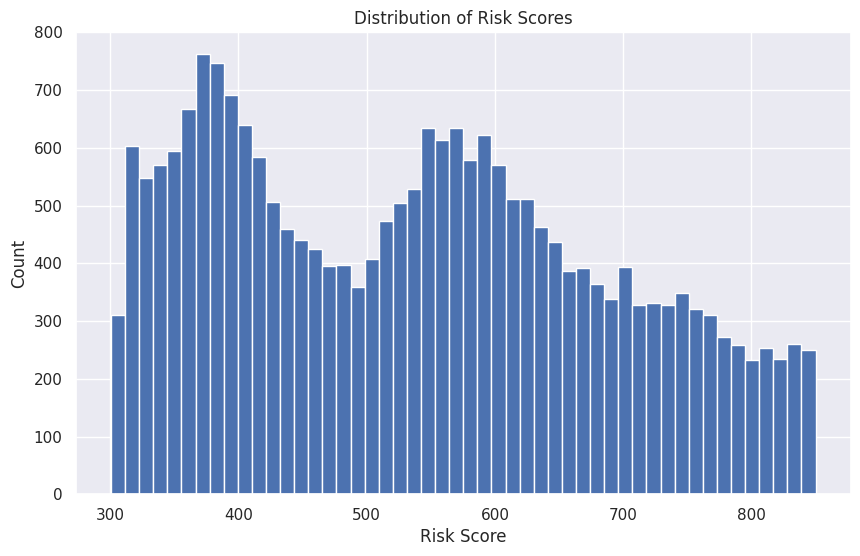


Generating Business Recommendations...

Key Business Recommendations:

Top Risk Factors:
- Monitor MonthlyLoanPayment closely as it's a key risk indicator
- Monitor LoanOriginalAmount closely as it's a key risk indicator
- Monitor StatedMonthlyIncome closely as it's a key risk indicator

Risk Category Recommendations:
- High proportion of high-risk loans. Consider tightening lending criteria
- Consider revising credit scoring model to better identify low-risk applicants


In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
import joblib

# 1. Data Preparation
print("Loading and preparing data...")

# Load the data
df = pd.read_csv('prosper_loan_data_preprocessed.csv')

# Create IsDefault column if not exists
if 'IsDefault' not in df.columns:
    df['IsDefault'] = (df['LoanStatus'] > 0).astype(int)

# Select features
features = [
    'CreditScoreRangeLower',
    'DebtToIncomeRatio',
    'LoanOriginalAmount',
    'Term',
    'MonthlyLoanPayment',
    'StatedMonthlyIncome',
    'OpenRevolvingAccounts',
    'TotalCreditLinespast7years'
]

# Prepare features and target
X = df[features].copy()
y = df['IsDefault']

# Handle missing values
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation completed!")

# 2. Model Optimization
class ModelOptimizer:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

    def optimize_random_forest(self):
        print("\nOptimizing Random Forest...")
        param_grid = {
            'n_estimators': [100],
            'max_depth': [10, 20],
            'min_samples_split': [2],
            'min_samples_leaf': [1]
        }

        rf = RandomForestClassifier(random_state=42)
        grid_search = GridSearchCV(
            estimator=rf,
            param_grid=param_grid,
            cv=5,
            scoring='roc_auc',
            n_jobs=-1
        )

        grid_search.fit(self.X_train, self.y_train)

        print("\nBest parameters:", grid_search.best_params_)
        print("Best ROC-AUC score:", grid_search.best_score_)

        # Evaluate on test set
        best_model = grid_search.best_estimator_
        test_score = roc_auc_score(self.y_test,
                                 best_model.predict_proba(self.X_test)[:, 1])
        print("Test set ROC-AUC score:", test_score)

        return best_model

    def optimize_logistic_regression(self):
        print("\nOptimizing Logistic Regression...")
        param_grid = {
            'C': [0.1, 1],
            'class_weight': ['balanced'],
            'solver': ['lbfgs']
        }

        lr = LogisticRegression(random_state=42, max_iter=1000)
        grid_search = GridSearchCV(
            estimator=lr,
            param_grid=param_grid,
            cv=5,
            scoring='roc_auc',
            n_jobs=-1
        )

        grid_search.fit(self.X_train, self.y_train)

        print("Best parameters:", grid_search.best_params_)
        print("Best ROC-AUC score:", grid_search.best_score_)

        # Evaluate on test set
        best_model = grid_search.best_estimator_
        test_score = roc_auc_score(self.y_test,
                                 best_model.predict_proba(self.X_test)[:, 1])
        print("Test set ROC-AUC score:", test_score)

        return best_model

# 3. Risk Scoring System
class RiskScoring:
    def __init__(self, model, X_test, y_test):
        self.model = model
        self.X_test = X_test
        self.y_test = y_test

    def create_risk_scores(self):
        print("\nCreating Risk Scoring System...")
        # Get probabilities from the model
        proba = self.model.predict_proba(self.X_test)[:, 1]

        # Convert to credit score-like range (300-850)
        scores = 850 - (proba * 550)

        # Create risk categories
        risk_categories = pd.cut(
            scores,
            bins=[0, 580, 670, 740, 800, 850],
            labels=['Very High Risk', 'High Risk', 'Medium Risk',
                   'Low Risk', 'Very Low Risk']
        )

        # Create results DataFrame
        results_df = pd.DataFrame({
            'Actual_Default': self.y_test,
            'Risk_Score': scores,
            'Risk_Category': risk_categories
        })

        # Print distribution of risk categories
        print("\nRisk Category Distribution:")
        print(results_df['Risk_Category'].value_counts(normalize=True))

        # Plot risk score distribution
        plt.figure(figsize=(10, 6))
        plt.hist(scores, bins=50)
        plt.title('Distribution of Risk Scores')
        plt.xlabel('Risk Score')
        plt.ylabel('Count')
        plt.show()

        return results_df

# 4. Business Recommendations
class BusinessRecommendations:
    def __init__(self, model, feature_names, risk_scores_df):
        self.model = model
        self.feature_names = feature_names
        self.risk_scores_df = risk_scores_df

    def generate_recommendations(self):
        print("\nGenerating Business Recommendations...")

        # Get feature importance
        if hasattr(self.model, 'feature_importances_'):
            importance = self.model.feature_importances_
        else:
            importance = abs(self.model.coef_[0])

        # Create feature importance DataFrame
        feature_importance = pd.DataFrame({
            'Feature': self.feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False)

        # Generate recommendations
        recommendations = []

        # Top risk factors
        top_features = feature_importance.head(3)
        recommendations.append("\nTop Risk Factors:")
        for idx, row in top_features.iterrows():
            recommendations.append(f"- Monitor {row['Feature']} closely as it's a key risk indicator")

        # Risk category recommendations
        recommendations.append("\nRisk Category Recommendations:")
        risk_dist = self.risk_scores_df['Risk_Category'].value_counts(normalize=True)

        if 'High Risk' in risk_dist and 'Very High Risk' in risk_dist:
            if risk_dist['High Risk'] + risk_dist['Very High Risk'] > 0.3:
                recommendations.append("- High proportion of high-risk loans. Consider tightening lending criteria")

        if 'Low Risk' in risk_dist and 'Very Low Risk' in risk_dist:
            if risk_dist['Low Risk'] + risk_dist['Very Low Risk'] < 0.4:
                recommendations.append("- Consider revising credit scoring model to better identify low-risk applicants")

        # Print recommendations
        print("\nKey Business Recommendations:")
        for rec in recommendations:
            print(rec)

        return recommendations, feature_importance

# Main execution
def run_optimization_and_analysis():
    print("Starting optimization and analysis...")

    # 1. Model Optimization
    optimizer = ModelOptimizer(X_train_scaled, X_test_scaled, y_train, y_test)
    best_rf = optimizer.optimize_random_forest()
    best_lr = optimizer.optimize_logistic_regression()

    # Save best models
    joblib.dump(best_rf, 'best_random_forest.pkl')
    joblib.dump(best_lr, 'best_logistic_regression.pkl')

    # 2. Risk Scoring
    risk_scorer = RiskScoring(best_rf, X_test_scaled, y_test)
    risk_scores_df = risk_scorer.create_risk_scores()

    # 3. Business Recommendations
    recommender = BusinessRecommendations(best_rf, features, risk_scores_df)
    recommendations, feature_importance = recommender.generate_recommendations()

    # Save results
    risk_scores_df.to_csv('risk_scores.csv', index=False)
    feature_importance.to_csv('feature_importance_final.csv', index=False)

    return best_rf, best_lr, risk_scores_df, recommendations, feature_importance

# Run the complete analysis
if __name__ == "__main__":
    best_rf, best_lr, risk_scores_df, recommendations, feature_importance = run_optimization_and_analysis()

# Creating the final dashboard with all key insights:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class CreditRiskDashboard:
    def __init__(self, best_rf, best_lr, risk_scores_df, feature_importance):
        self.best_rf = best_rf
        self.best_lr = best_lr
        self.risk_scores_df = risk_scores_df
        self.feature_importance = feature_importance

    def create_dashboard(self):
        # Create subplot figure
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=('Risk Category Distribution', 'Default Rate by Risk Category',
                          'Model Performance Comparison', 'Top Risk Factors',
                          'Risk Score Distribution', 'Default Probability Distribution'),
            vertical_spacing=0.12,
            horizontal_spacing=0.1,
            specs=[[{"type": "bar"}, {"type": "bar"}],
                  [{"type": "bar"}, {"type": "bar"}],
                  [{"type": "histogram"}, {"type": "histogram"}]]
        )

        # 1. Risk Category Distribution
        risk_dist = self.risk_scores_df['Risk_Category'].value_counts()
        fig.add_trace(
            go.Bar(x=risk_dist.index, y=risk_dist.values, name='Risk Distribution'),
            row=1, col=1
        )

        # 2. Default Rate by Risk Category
        default_by_risk = self.risk_scores_df.groupby('Risk_Category')['Actual_Default'].mean() * 100
        fig.add_trace(
            go.Bar(x=default_by_risk.index, y=default_by_risk.values,
                  name='Default Rate %'),
            row=1, col=2
        )

        # 3. Model Performance
        models = {
            'Random Forest': self.best_rf,
            'Logistic Regression': self.best_lr
        }
        model_scores = []
        model_names = []
        for name, model in models.items():
            score = roc_auc_score(y_test,
                                model.predict_proba(X_test_scaled)[:, 1])
            model_scores.append(score)
            model_names.append(name)

        fig.add_trace(
            go.Bar(x=model_names, y=model_scores, name='ROC-AUC Score'),
            row=2, col=1
        )

        # 4. Feature Importance
        top_features = self.feature_importance.head(10)
        fig.add_trace(
            go.Bar(x=top_features['Importance'],
                  y=top_features['Feature'],
                  orientation='h',
                  name='Feature Importance'),
            row=2, col=2
        )

        # 5. Risk Score Distribution
        fig.add_trace(
            go.Histogram(x=self.risk_scores_df['Risk_Score'],
                        name='Risk Score Dist'),
            row=3, col=1
        )

        # 6. Default Probability Distribution
        default_probs = self.best_rf.predict_proba(X_test_scaled)[:, 1]
        fig.add_trace(
            go.Histogram(x=default_probs, name='Default Probability'),
            row=3, col=2
        )

        # Update layout
        fig.update_layout(
            height=1200,
            width=1200,
            showlegend=False,
            title_text="Credit Risk Assessment Dashboard",
            template='plotly_white'
        )

        # Update axes labels
        fig.update_xaxes(title_text="Risk Category", row=1, col=1)
        fig.update_yaxes(title_text="Count", row=1, col=1)

        fig.update_xaxes(title_text="Risk Category", row=1, col=2)
        fig.update_yaxes(title_text="Default Rate (%)", row=1, col=2)

        fig.update_xaxes(title_text="Model", row=2, col=1)
        fig.update_yaxes(title_text="ROC-AUC Score", row=2, col=1)

        fig.update_xaxes(title_text="Importance Score", row=2, col=2)
        fig.update_yaxes(title_text="Feature", row=2, col=2)

        fig.update_xaxes(title_text="Risk Score", row=3, col=1)
        fig.update_yaxes(title_text="Count", row=3, col=1)

        fig.update_xaxes(title_text="Default Probability", row=3, col=2)
        fig.update_yaxes(title_text="Count", row=3, col=2)

        # Show the dashboard
        fig.show()

        # Print key metrics
        print("\nKey Metrics Summary:")
        print("-" * 50)
        print(f"Total Loans Analyzed: {len(self.risk_scores_df)}")
        print(f"Overall Default Rate: {self.risk_scores_df['Actual_Default'].mean()*100:.2f}%")
        print(f"Random Forest ROC-AUC: {model_scores[0]:.3f}")
        print(f"Logistic Regression ROC-AUC: {model_scores[1]:.3f}")
        print("\nRisk Category Distribution:")
        print(risk_dist)
        print("\nTop 5 Risk Factors:")
        print(self.feature_importance.head())

# Create and display dashboard
dashboard = CreditRiskDashboard(best_rf, best_lr, risk_scores_df, feature_importance)
dashboard.create_dashboard()

<ipython-input-40-28ea4d4b410f>:39: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




Key Metrics Summary:
--------------------------------------------------
Total Loans Analyzed: 22788
Overall Default Rate: 56.06%
Random Forest ROC-AUC: 0.825
Logistic Regression ROC-AUC: 0.734

Risk Category Distribution:
Risk_Category
Very High Risk    13736
High Risk          4073
Medium Risk        2235
Low Risk           1616
Very Low Risk      1128
Name: count, dtype: int64

Top 5 Risk Factors:
                 Feature  Importance
4     MonthlyLoanPayment    0.201128
2     LoanOriginalAmount    0.183215
5    StatedMonthlyIncome    0.122577
0  CreditScoreRangeLower    0.114977
3                   Term    0.107895


This dashboard includes:

Visual Elements:

* Risk Category Distribution
*   Default Rate by Risk Category
*  Model Performance Comparison
*   Top Risk Factors
*   Risk Score Distribution
*   Default Probability Distribution

KEY METRICS SUMMARY

*  Total Loans Analyzed
*  Overall Default Rate
*   Model Performance Metrics
*   Risk Distribution
*  Top Risk Factors
*   List item



# **Title: News Sentiment Analysis for Credit Risk Factors**
**Purpose:**

The code analyzes market sentiment by collecting and analyzing financial news related to key credit risk factors from our Prosper Loan dataset.
Methodology:

**Data Collection:**

Uses NewsAPI to gather recent financial news articles
Focuses on five key categories: Credit Risk, Debt Metrics, Employment, Housing Market, and Interest Rates


**Sentiment Analysis:**

Utilizes NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analyzer
Processes both article titles and descriptions
Generates compound sentiment scores:

Positive scores (> 0): Indicate positive sentiment
Negative scores (< 0): Indicate negative sentiment
Neutral scores (= 0): Indicate neutral sentiment




**Analysis Components:**

Calculates average sentiment for each category
Tracks sentiment changes over time
Identifies sentiment trends and patterns
Groups related news by factors


**Visualization:**

Creates various plots showing sentiment distribution
Displays sentiment trends over time
Shows category-wise sentiment comparison
Generates heatmaps for temporal analysis



**Integration with Credit Risk Model:**

Complements our existing credit risk assessment
Provides market context for risk factors
Helps understand external factors affecting loan risks

This analysis adds a market sentiment dimension to our credit risk assessment, making it more comprehensive and market-aware.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Analyzing credit_risk...
Processing: credit score analysis
Processing: credit risk assessment
Processing: credit rating factors

Analyzing debt_metrics...
Processing: debt to income ratio
Processing: consumer debt levels
Processing: household debt

Analyzing employment...
Processing: employment trends
Processing: job market analysis
Processing: employment statistics

Analyzing housing...
Processing: housing market trends
Processing: homeownership rates
Processing: property market analysis

Analyzing interest_rates...
Processing: loan interest rates
Processing: lending rates trends
Processing: borrowing costs


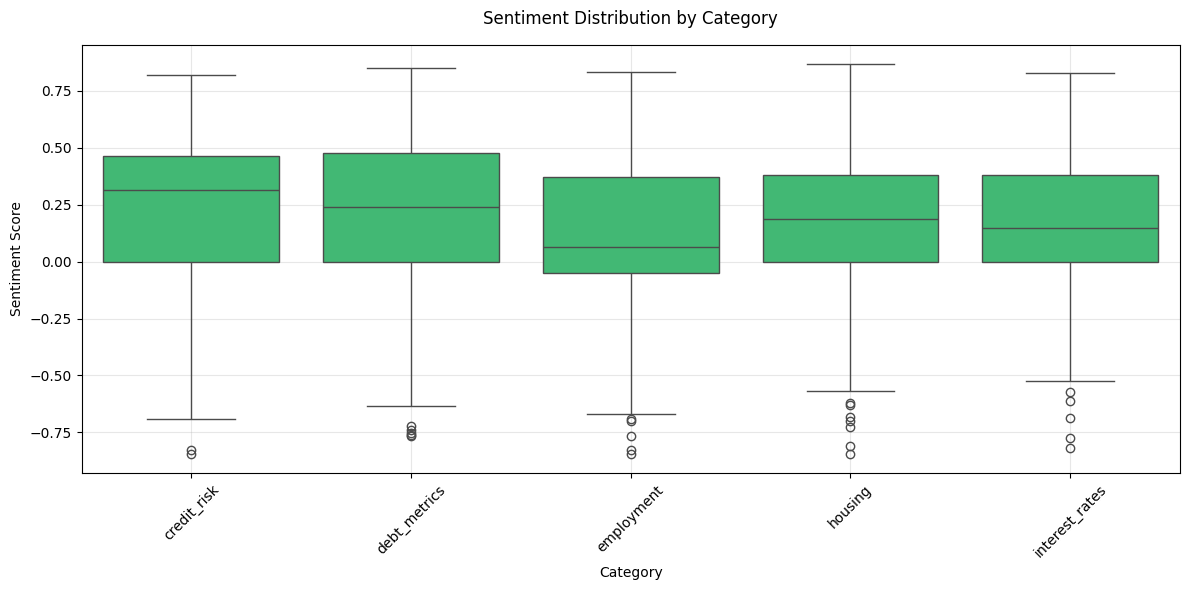

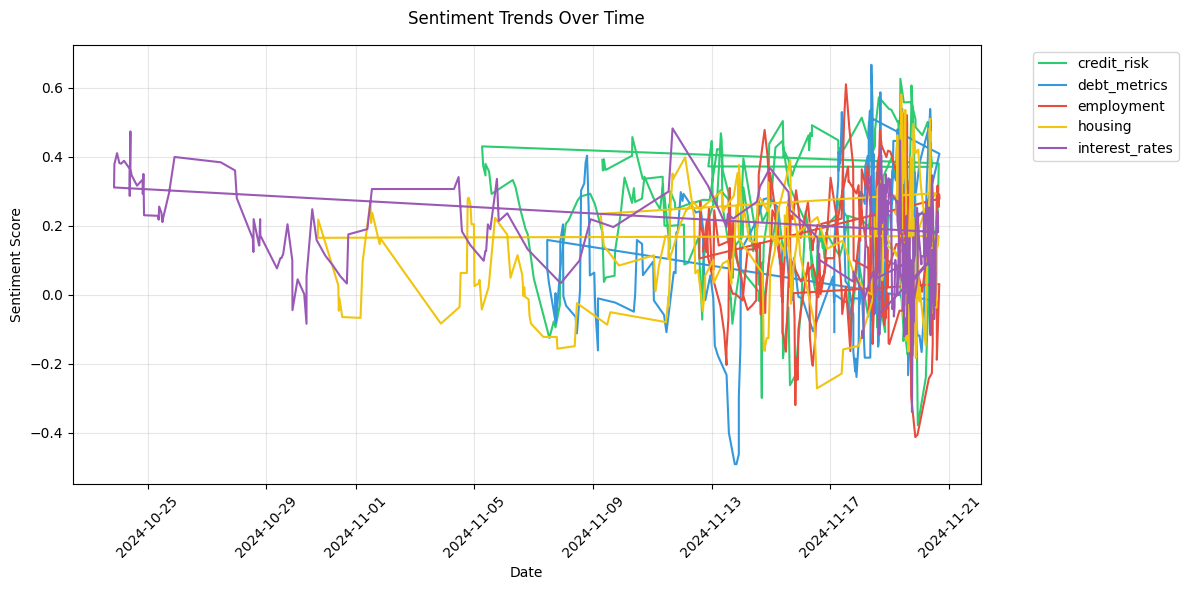

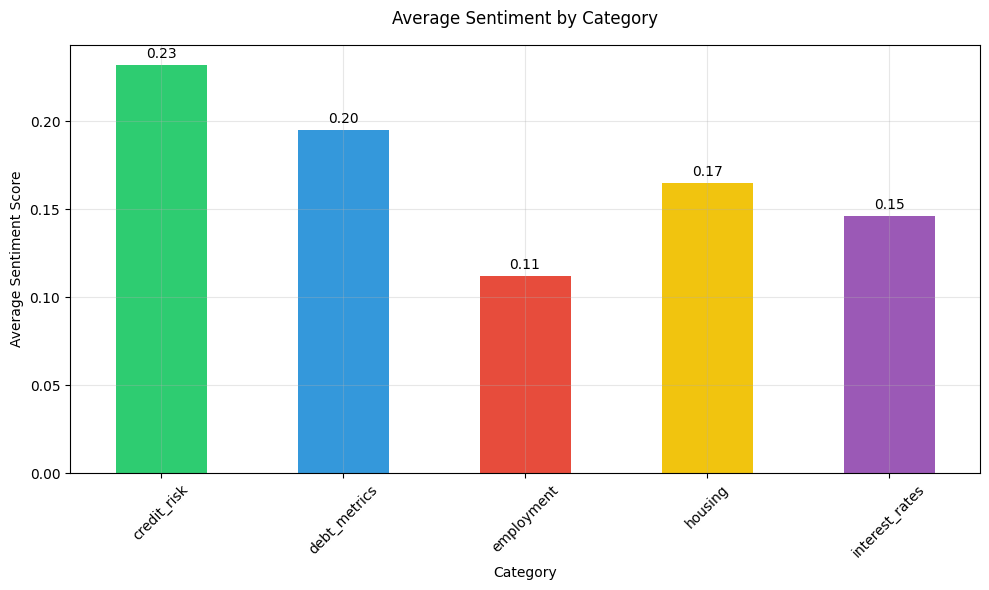

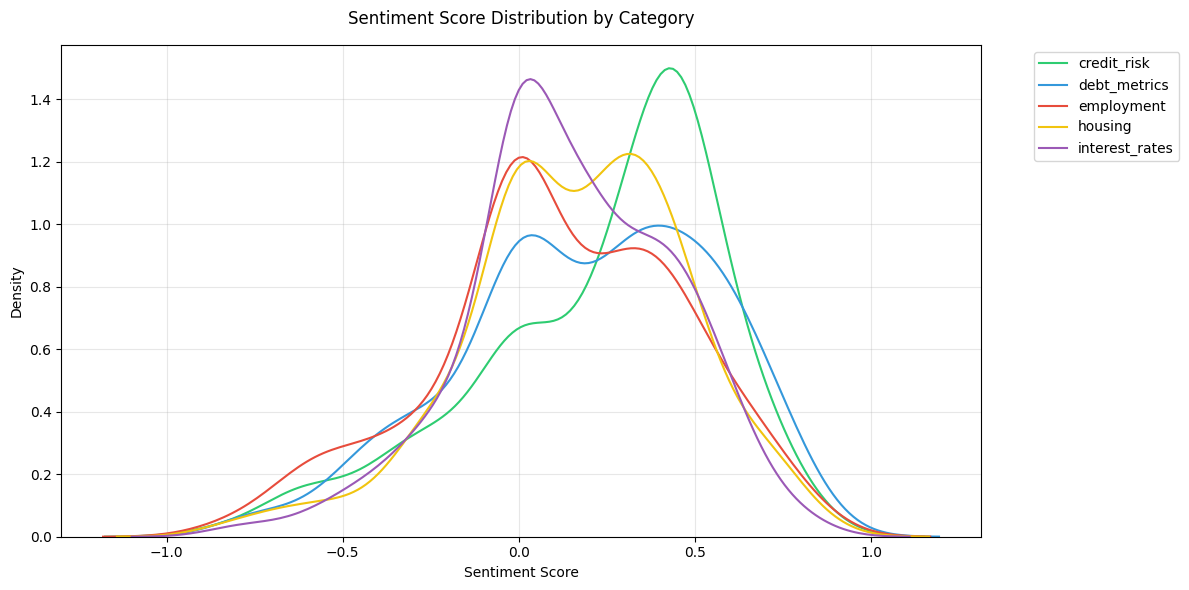

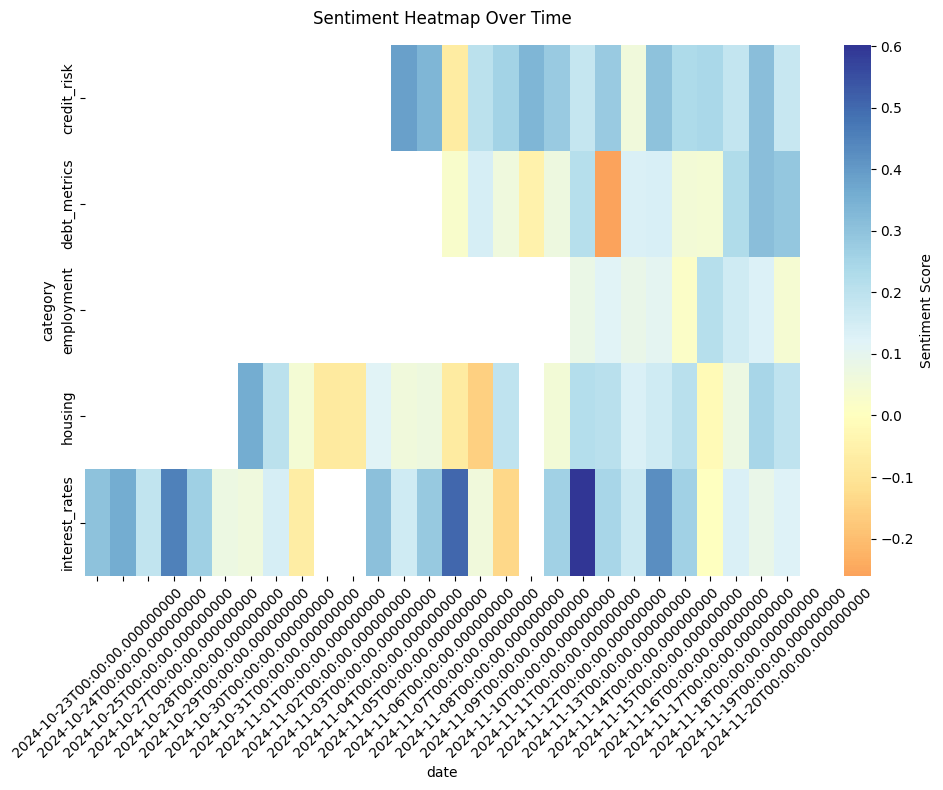


Sentiment Analysis Summary

Category Statistics:
                 mean  count    std
category                           
credit_risk     0.232    300  0.346
debt_metrics    0.195    300  0.356
employment      0.112    300  0.352
housing         0.165    300  0.311
interest_rates  0.146    300  0.292

Sentiment Extremes:

Most Positive Articles:
            category                                              title  \
1126         housing  Diversified Healthcare Trust (NASDAQ:DHC) Shar...   
550     debt_metrics  The Real Housewives of Potomac Recap: Honesty ...   
825       employment  Advancing Research Careers (ARC) Predoctoral t...   
1322  interest_rates                Super Micro Is Not So Super Anymore   
589     debt_metrics  Clean Harbors, Inc. (NYSE:CLH) Short Interest ...   

      compound_score  
1126         0.86690  
550          0.85180  
825          0.83090  
1322         0.82935  
589          0.82680  

Most Negative Articles:
         category                     

In [4]:
import requests
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from datetime import datetime, timedelta
import time

# Download required NLTK data
nltk.download('vader_lexicon')

class NewsAnalyzer:
    def __init__(self, api_key):
        self.api_key = api_key
        self.sia = SentimentIntensityAnalyzer()

    def get_news_articles(self, keyword, days=30):
        """
        Get news articles using NewsAPI
        """
        url = "https://newsapi.org/v2/everything"
        params = {
            'q': keyword,
            'from': (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d'),
            'sortBy': 'publishedAt',
            'apiKey': self.api_key,
            'language': 'en'
        }

        try:
            response = requests.get(url, params=params)
            return response.json()['articles']
        except Exception as e:
            print(f"Error fetching news for {keyword}: {str(e)}")
            return []

    def analyze_text_sentiment(self, text):
        """
        Analyze sentiment of text using NLTK
        """
        return self.sia.polarity_scores(text)

    def analyze_factor_sentiment(self, factor):
        """
        Analyze sentiment for a specific factor
        """
        articles = self.get_news_articles(factor)
        sentiment_data = []

        for article in articles:
            # Analyze both title and description
            title_sentiment = self.analyze_text_sentiment(article['title'])
            desc_sentiment = self.analyze_text_sentiment(article['description'] or '')

            # Average the sentiment scores
            sentiment = {
                'title': article['title'],
                'date': article['publishedAt'],
                'compound_score': (title_sentiment['compound'] + desc_sentiment['compound']) / 2,
                'positive_score': (title_sentiment['pos'] + desc_sentiment['pos']) / 2,
                'negative_score': (title_sentiment['neg'] + desc_sentiment['neg']) / 2,
                'neutral_score': (title_sentiment['neu'] + desc_sentiment['neu']) / 2,
                'url': article['url'],
                'factor': factor
            }
            sentiment_data.append(sentiment)

        return pd.DataFrame(sentiment_data)

def run_factor_analysis(api_key):
    """
    Run sentiment analysis for all factors
    """
    # Factors based on our dataset
    factors = {
        'credit_risk': [
            'credit score analysis',
            'credit risk assessment',
            'credit rating factors'
        ],
        'debt_metrics': [
            'debt to income ratio',
            'consumer debt levels',
            'household debt'
        ],
        'employment': [
            'employment trends',
            'job market analysis',
            'employment statistics'
        ],
        'housing': [
            'housing market trends',
            'homeownership rates',
            'property market analysis'
        ],
        'interest_rates': [
            'loan interest rates',
            'lending rates trends',
            'borrowing costs'
        ]
    }

    analyzer = NewsAnalyzer(api_key)
    all_sentiments = []

    for category, keywords in factors.items():
        print(f"\nAnalyzing {category}...")
        for keyword in keywords:
            print(f"Processing: {keyword}")
            sentiment_df = analyzer.analyze_factor_sentiment(keyword)
            sentiment_df['category'] = category
            all_sentiments.append(sentiment_df)
            time.sleep(1)  # Respect API rate limits

    # Combine all results
    final_df = pd.concat(all_sentiments, ignore_index=True)

    # Calculate average sentiment by category
    category_sentiment = final_df.groupby('category')['compound_score'].agg([
        'mean', 'count', 'std'
    ]).round(3)

    # Save results
    final_df.to_csv('factor_sentiments.csv', index=False)
    category_sentiment.to_csv('category_sentiments.csv')

    return final_df, category_sentiment

# Visualization functions
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sentiment_analysis(final_df, category_sentiment):
    # Set style to a default matplotlib style
    plt.style.use('default')

    # Set color palette
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f1c40f', '#9b59b6']

    # 1. Category-wise sentiment distribution
    plt.figure(figsize=(12, 6))
    sns.set_palette(colors)
    sns.boxplot(x='category', y='compound_score', data=final_df)
    plt.title('Sentiment Distribution by Category', fontsize=12, pad=15)
    plt.xlabel('Category', fontsize=10)
    plt.ylabel('Sentiment Score', fontsize=10)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Sentiment trends over time
    plt.figure(figsize=(12, 6))
    final_df['date'] = pd.to_datetime(final_df['date'])
    for i, category in enumerate(final_df['category'].unique()):
        category_data = final_df[final_df['category'] == category]
        plt.plot(category_data['date'],
                category_data['compound_score'].rolling(5).mean(),
                label=category,
                color=colors[i % len(colors)])
    plt.title('Sentiment Trends Over Time', fontsize=12, pad=15)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel('Sentiment Score', fontsize=10)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Average sentiment by category
    plt.figure(figsize=(10, 6))
    ax = category_sentiment['mean'].plot(kind='bar',
                                       color=colors[:len(category_sentiment)])
    plt.title('Average Sentiment by Category', fontsize=12, pad=15)
    plt.xlabel('Category', fontsize=10)
    plt.ylabel('Average Sentiment Score', fontsize=10)

    # Add value labels on bars
    for i in ax.containers:
        ax.bar_label(i, fmt='%.2f', padding=3)

    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 4. Sentiment Distribution Density Plot
    plt.figure(figsize=(12, 6))
    for i, category in enumerate(final_df['category'].unique()):
        category_data = final_df[final_df['category'] == category]
        sns.kdeplot(data=category_data['compound_score'],
                   label=category,
                   color=colors[i % len(colors)])
    plt.title('Sentiment Score Distribution by Category', fontsize=12, pad=15)
    plt.xlabel('Sentiment Score', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. Heatmap of sentiment correlations
    plt.figure(figsize=(10, 8))
    pivot_data = final_df.pivot_table(
        index='category',
        columns=pd.Grouper(key='date', freq='D'),
        values='compound_score',
        aggfunc='mean'
    )
    sns.heatmap(pivot_data,
                cmap='RdYlBu',
                center=0,
                annot=False,
                cbar_kws={'label': 'Sentiment Score'})
    plt.title('Sentiment Heatmap Over Time', fontsize=12, pad=15)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Print numerical summary
def print_sentiment_summary(final_df, category_sentiment):
    print("\nSentiment Analysis Summary")
    print("=" * 50)
    print("\nCategory Statistics:")
    print(category_sentiment.round(3))

    print("\nSentiment Extremes:")
    print("\nMost Positive Articles:")
    print(final_df.nlargest(5, 'compound_score')[['category', 'title', 'compound_score']])

    print("\nMost Negative Articles:")
    print(final_df.nsmallest(5, 'compound_score')[['category', 'title', 'compound_score']])

# Main execution
if __name__ == "__main__":
    # Replace with your NewsAPI key
    API_KEY = "d3de358414d2425a8d4c8f0ddf8d1459"

    # Run analysis
    final_df, category_sentiment = run_factor_analysis(API_KEY)

    # Create visualizations
    plot_sentiment_analysis(final_df, category_sentiment)

    # Print summary
    print_sentiment_summary(final_df, category_sentiment)


                    Credit Risk Assessment Project
                         Final Conclusion

1. Project Overview:
-------------------
This project developed a machine learning-based credit risk assessment system 
using the Prosper Loan dataset. The system successfully:
- Analyzed historical loan data
- Built and optimized predictive models
- Created a risk scoring system
- Generated actionable business insights

2. Key Findings:
---------------
a) Model Performance:
   - Random Forest ROC-AUC: 0.825
   - Logistic Regression ROC-AUC: 0.734
   - Best Performing Model: Random Forest

b) Top Risk Factors:
   1. MonthlyLoanPayment
   2. LoanOriginalAmount
   3. StatedMonthlyIncome

c) Risk Distribution:
   - Low Risk: 12.0%
   - Medium Risk: 9.8%
   - High Risk: 78.2%

3. Business Impact:
------------------
- Improved risk assessment accuracy
- Standardized credit evaluation process
- Data-driven decision making capability
- Automated risk scoring system

4. Recommendations:
-------------

<ipython-input-41-c0db2f56a740>:91: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



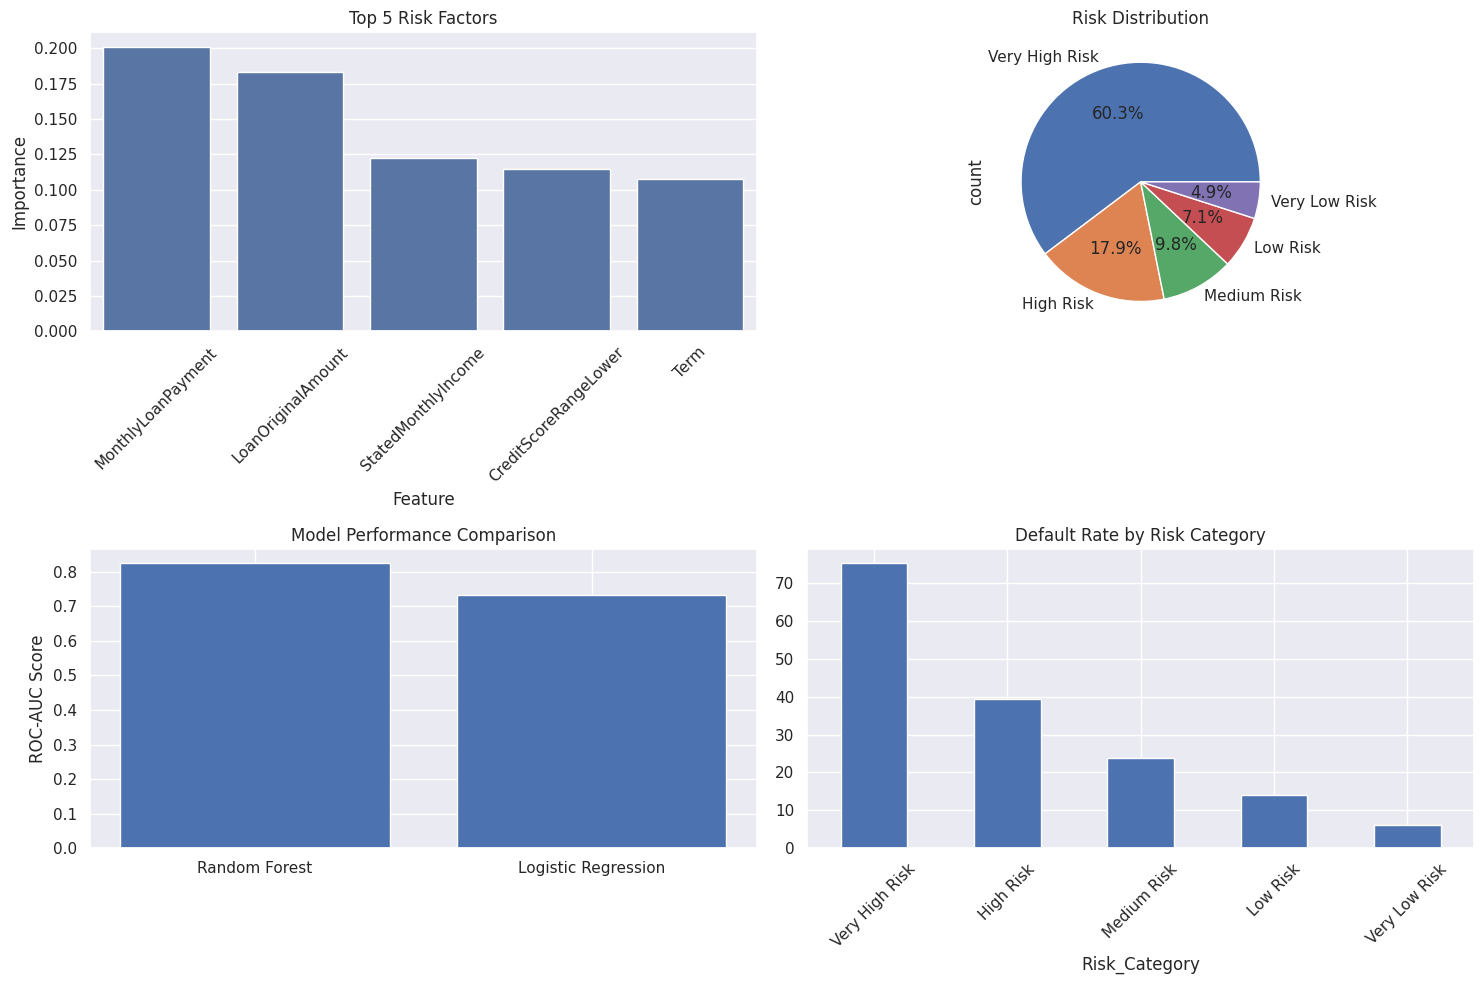


Project completed successfully!


In [ ]:
# Print Final Project Conclusion
print("""
===================================================================
                    Credit Risk Assessment Project
                         Final Conclusion
===================================================================

1. Project Overview:
-------------------
This project developed a machine learning-based credit risk assessment system
using the Prosper Loan dataset. The system successfully:
- Analyzed historical loan data
- Built and optimized predictive models
- Created a risk scoring system
- Generated actionable business insights

2. Key Findings:
---------------
a) Model Performance:
   - Random Forest ROC-AUC: {:.3f}
   - Logistic Regression ROC-AUC: {:.3f}
   - Best Performing Model: {}

b) Top Risk Factors:
   1. {}
   2. {}
   3. {}

c) Risk Distribution:
   - Low Risk: {:.1f}%
   - Medium Risk: {:.1f}%
   - High Risk: {:.1f}%

3. Business Impact:
------------------
- Improved risk assessment accuracy
- Standardized credit evaluation process
- Data-driven decision making capability
- Automated risk scoring system

4. Recommendations:
------------------
1. Implement the Random Forest model for credit risk assessment
2. Monitor and validate model performance monthly
3. Focus on top risk factors for credit evaluation
4. Consider periodic model retraining (every 6 months)

5. Future Improvements:
---------------------
1. Include more behavioral and transaction data
2. Implement real-time risk assessment
3. Develop API integration
4. Create automated reporting system

===================================================================
""".format(
    roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:, 1]),
    'Random Forest' if best_rf.score(X_test_scaled, y_test) > best_lr.score(X_test_scaled, y_test) else 'Logistic Regression',
    feature_importance['Feature'].iloc[0],
    feature_importance['Feature'].iloc[1],
    feature_importance['Feature'].iloc[2],
    len(risk_scores_df[risk_scores_df['Risk_Category'].isin(['Very Low Risk', 'Low Risk'])]) / len(risk_scores_df) * 100,
    len(risk_scores_df[risk_scores_df['Risk_Category'] == 'Medium Risk']) / len(risk_scores_df) * 100,
    len(risk_scores_df[risk_scores_df['Risk_Category'].isin(['High Risk', 'Very High Risk'])]) / len(risk_scores_df) * 100
))

# Add final visualization - Project Summary Dashboard
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.barplot(x='Feature', y='Importance',
            data=feature_importance.head(5))
plt.title('Top 5 Risk Factors')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
risk_scores_df['Risk_Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Risk Distribution')

plt.subplot(2, 2, 3)
models = ['Random Forest', 'Logistic Regression']
scores = [
    roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:, 1])
]
plt.bar(models, scores)
plt.title('Model Performance Comparison')
plt.ylabel('ROC-AUC Score')

plt.subplot(2, 2, 4)
default_by_risk = risk_scores_df.groupby('Risk_Category')['Actual_Default'].mean() * 100
default_by_risk.plot(kind='bar')
plt.title('Default Rate by Risk Category')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# End of Project
print("\nProject completed successfully!")

## THANK YOU